In [55]:
import numpy as np 
import pandas as pd
from scipy.optimize import minimize
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt 

# Load file and visualise

In [ ]:
# Load file
df = pd.read_csv('../../data/synthetic/synthetic_data_independent_views.csv')

# Inspect
print(df.head())
print(df.columns)

   gen  time view  point    coord1    coord2
0    1   1.0   xz      1 -0.024226  0.000481
1    1   1.0   xz      2 -0.024226  0.000481
2    1   1.0   xz      3 -0.024226  0.000481
3    1   1.0   xz      4 -0.024226  0.000481
4    1   1.0   xz      5  0.002324 -0.000129
Index(['gen', 'time', 'view', 'point', 'coord1', 'coord2'], dtype='str')


Single snapshot plot:

In [57]:
# generation 1 time 5
g = 1
t = 5

subset = df[(df['gen'] == g) & (df['time'] == t)]

# split into projections 
xz = subset[subset['view'] == 'xz']
yz = subset[subset['view'] == 'yz']

# to numpy array 
xz = xz.sort_values('point')
yz = yz.sort_values('point')

x = xz['coord1'].values
z_xz = xz['coord2'].values

y = yz['coord1'].values
z_yz = yz['coord2'].values

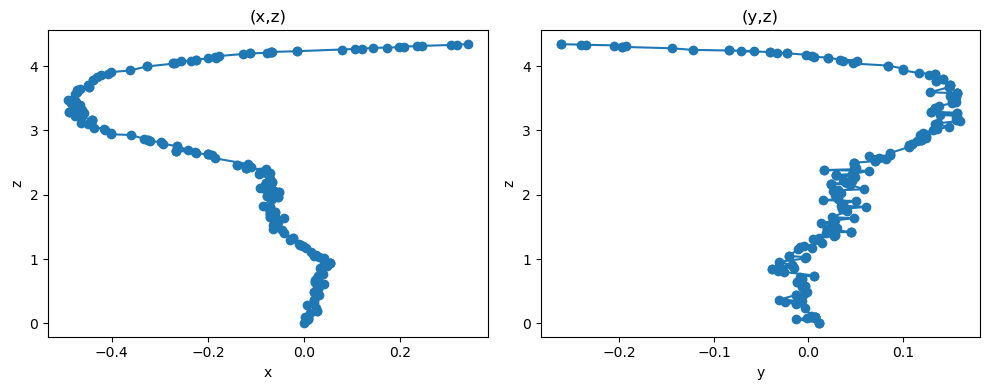

In [58]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(x, z_xz, '-o')
plt.title('(x,z)')
plt.xlabel('x'); plt.ylabel('z')

plt.subplot(1,2,2)
plt.plot(y, z_yz, '-o')
plt.title('(y,z)')
plt.xlabel('y'); plt.ylabel('z')

plt.tight_layout()
plt.show()

Save visualisation as a function:
Use as 

x_obs, z_xz, y_obs, z_yz = load_snapshot(df, gen=1, time=5)

In [59]:
def load_snapshot(df, gen, time):
    subset = df[(df['gen']==gen) & (df['time']==time)]
    
    xz = subset[subset['view']=='xz'].sort_values('point')
    yz = subset[subset['view']=='yz'].sort_values('point')
    
    x_obs = xz['coord1'].values
    z_xz  = xz['coord2'].values
    
    y_obs = yz['coord1'].values
    z_yz  = yz['coord2'].values
    
    return x_obs, z_xz, y_obs, z_yz

x_obs, z_xz, y_obs, z_yz = load_snapshot(df, 1, 5)


# 3D Curve Reconstruction

## Initial guess for the curve
The initial guess comes directly from interpolating the points. 

In [60]:
N = 100 # reconsturction resolution

z0 = np.linspace(np.min(z_xz), np.max(z_xz), N)
x0 = np.interp(z0, z_xz, x_obs)
y0 = np.interp(z0, z_yz, y_obs)

X0 = np.vstack([x0, y0, z0]).T

## Mean curve
Repeatedly smooths the curve using the second derivative, this is a curvature regularisation. 

In [61]:
X = X0.copy()

for _ in range(25):
    D2 = X[2:] - 2*X[1:-1] + X[:-2]
    X[1:-1] += 0.1 * D2   # smoothing strength


## Enforce arc-length reparameterisation

In [62]:
def reparametrize_uniform(X, N):
    d = np.linalg.norm(X[1:] - X[:-1], axis=1)
    s = np.concatenate([[0], np.cumsum(d)])
    s /= s[-1]

    s_new = np.linspace(0,1,N)

    X_new = np.zeros((N, 3))
    for i in range(3):
        X_new[:,i] = np.interp(s_new, s, X[:,i])

    return X_new

X_uniform = reparametrize_uniform(X, N)

# Visualize

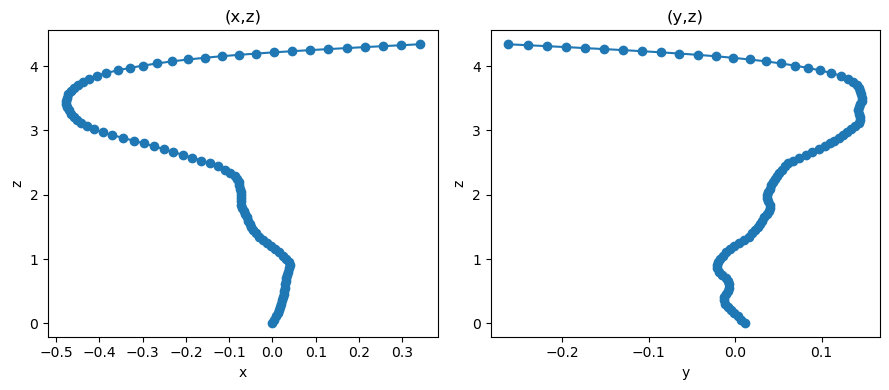

In [63]:
plt.figure(figsize=(9,4))

plt.subplot(1,2,1)
plt.plot(X_uniform[:,0], X_uniform[:,2], '-o')
plt.title('(x,z)')
plt.xlabel('x'); plt.ylabel('z')

plt.subplot(1,2,2)
plt.plot(X_uniform[:,1], X_uniform[:,2], '-o')
plt.title('(y,z)')
plt.xlabel('y'); plt.ylabel('z')

plt.tight_layout()
plt.show()

# A full time simulation

In [64]:
def process_snapshot(x_obs, y_obs, z_obs, N_out=100, smooth_iter=25, smooth_strength=0.1):
    """
    Build smooth, arc-length parameterized curve from ordered noisy data.
    """

    # --- Step 1: stack raw 3D curve ---
    X = np.vstack([x_obs, y_obs, z_obs]).T

    # --- Step 2: smooth (curvature regularization) ---
    X_smooth = X.copy()
    for _ in range(smooth_iter):
        D2 = X_smooth[2:] - 2*X_smooth[1:-1] + X_smooth[:-2]
        X_smooth[1:-1] += smooth_strength * D2

    # --- Step 3: reparameterize to uniform arc-length ---
    d = np.linalg.norm(X_smooth[1:] - X_smooth[:-1], axis=1)
    s = np.concatenate([[0], np.cumsum(d)])
    s /= s[-1]

    s_new = np.linspace(0,1,N_out)

    X_final = np.zeros((N_out, 3))
    for i in range(3):
        X_final[:,i] = np.interp(s_new, s, X_smooth[:,i])

    return X_final

In [65]:
results = {}

gens = df['gen'].unique()
times = df['time'].unique()

for g in gens:
    for t in times:
        subset = df[(df['gen']==g) & (df['time']==t)]

        xz = subset[subset['view']=='xz'].sort_values('point')
        yz = subset[subset['view']=='yz'].sort_values('point')

        x_obs = xz['coord1'].values
        z_xz  = xz['coord2'].values

        y_obs = yz['coord1'].values
        z_yz  = yz['coord2'].values

        # --- small consistency fix (important) ---
        z_obs = 0.5 * (z_xz + z_yz)

        # --- process ---
        X_final = process_snapshot(x_obs, y_obs, z_obs)

        # --- store ---
        results[(g, t)] = X_final

        print(f"Processed gen={g}, time={t}")

Processed gen=1, time=1.0
Processed gen=1, time=3.0
Processed gen=1, time=5.0
Processed gen=1, time=7.0
Processed gen=1, time=9.0
Processed gen=2, time=1.0
Processed gen=2, time=3.0
Processed gen=2, time=5.0
Processed gen=2, time=7.0
Processed gen=2, time=9.0
Processed gen=3, time=1.0
Processed gen=3, time=3.0
Processed gen=3, time=5.0
Processed gen=3, time=7.0
Processed gen=3, time=9.0
Processed gen=4, time=1.0
Processed gen=4, time=3.0
Processed gen=4, time=5.0
Processed gen=4, time=7.0
Processed gen=4, time=9.0
Processed gen=5, time=1.0
Processed gen=5, time=3.0
Processed gen=5, time=5.0
Processed gen=5, time=7.0
Processed gen=5, time=9.0
Processed gen=6, time=1.0
Processed gen=6, time=3.0
Processed gen=6, time=5.0
Processed gen=6, time=7.0
Processed gen=6, time=9.0
Processed gen=7, time=1.0
Processed gen=7, time=3.0
Processed gen=7, time=5.0
Processed gen=7, time=7.0
Processed gen=7, time=9.0
Processed gen=8, time=1.0
Processed gen=8, time=3.0
Processed gen=8, time=5.0
Processed ge

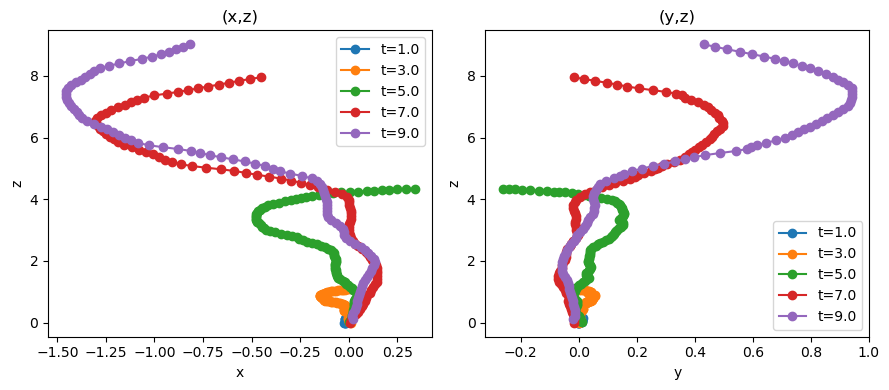

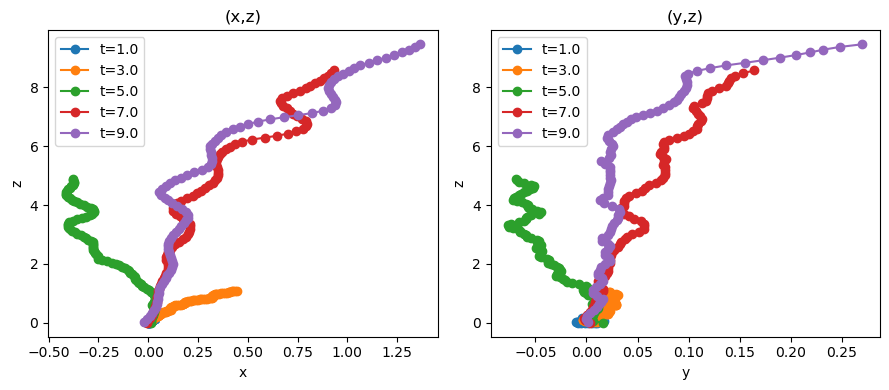

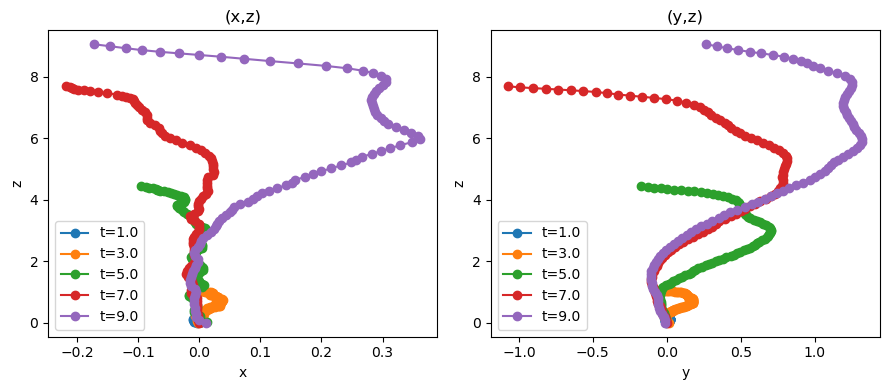

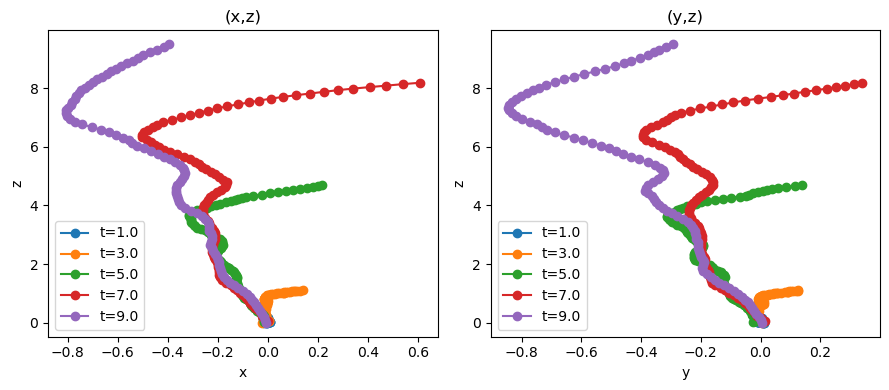

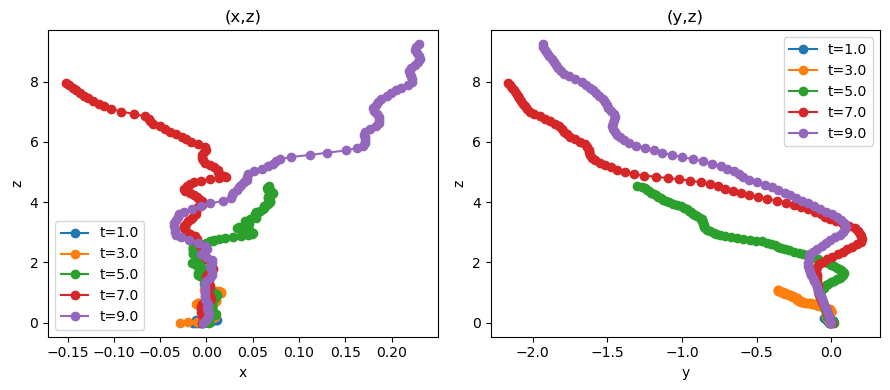

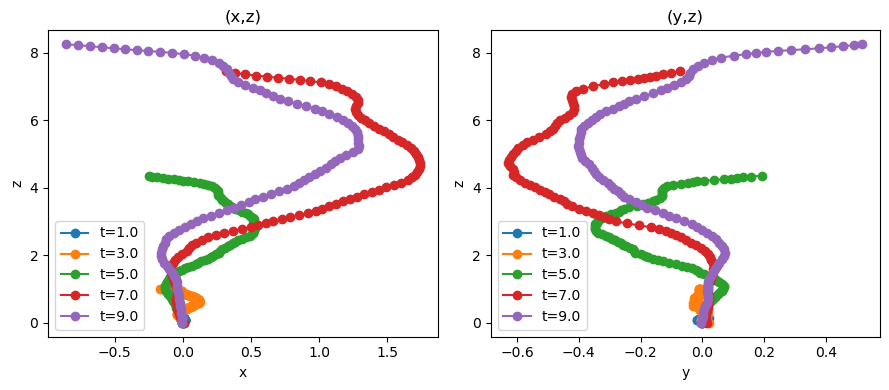

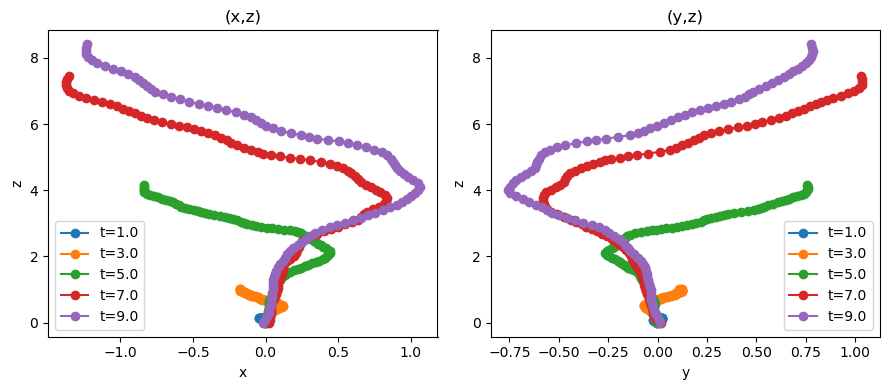

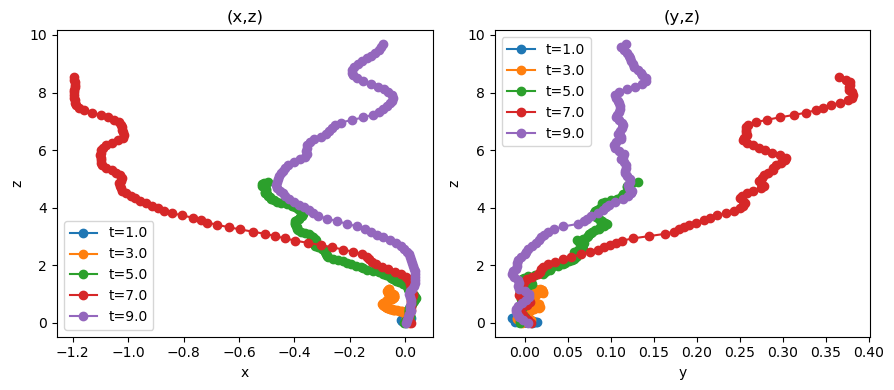

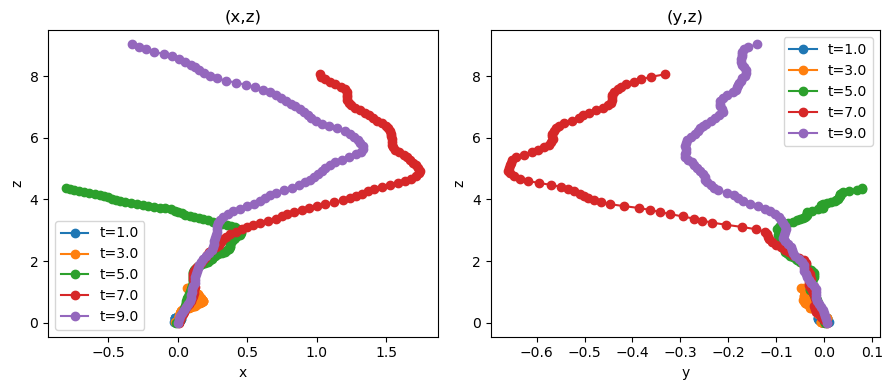

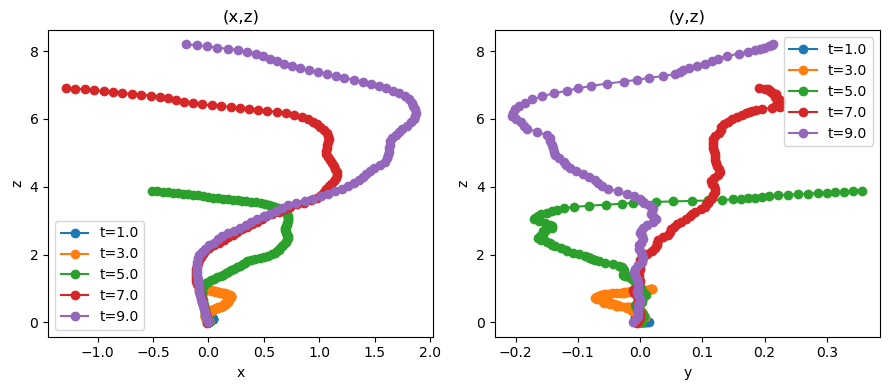

In [69]:
for g in gens:
    plt.figure(figsize=(9,4))

    plt.subplot(1,2,1)
    plt.title('(x,z)')
    plt.xlabel('x'); plt.ylabel('z')

    plt.subplot(1,2,2)
    plt.title('(y,z)')
    plt.xlabel('y'); plt.ylabel('z')

    for t in times:
        X = results[(g, t)]

        # left subplot (XZ)
        plt.subplot(1,2,1)
        plt.plot(X[:,0], X[:,2], '-o', label=f't={t}')

        # right subplot (YZ)
        plt.subplot(1,2,2)
        plt.plot(X[:,1], X[:,2], '-o', label=f't={t}')

    plt.subplot(1,2,1)
    plt.legend()

    plt.subplot(1,2,2)
    plt.legend()

    plt.tight_layout()
    plt.show()